In [1]:
# Code to test everything is working fine. 
import os 
import sys
sys.path.append("../../")


import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.saving import save_model, load_model
from vi_rnn.datasets import DTTDataset

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params

import pandas as pd 

from sklearn.model_selection import train_test_split, KFold

from data.utils import * 

from evaluation.calc_stats import calc_isi_stats
from scipy.signal import convolve, gaussian
%matplotlib inline

### Load spikes and neuromodulation signal

In [2]:
data_dir = '../../data/recordings/nk341_mPFC/' 
out_dir = "../../models/dtt/" 

sampling_rate = 30_000 # khz
t_start_baseline, t_end_baseline = 10, 600
t_start_post_trial, t_end_post_trial = 6_969, 7_869
bin_size = 0.02
bs = 256 # batch size 

deconvolve = False
convolve_spikes = True  
z_score = False 
center = True 

In [3]:
def load_data():
    spikes = []

    spikes_dir = os.path.join(data_dir, 'spikes')

    t_start, t_end = 10, 0
    for f in os.listdir(spikes_dir):
        spikes_df = pd.read_csv(f'{spikes_dir}/{f}', header=None)
        spikes.append(spikes_df.to_numpy().flatten() / sampling_rate)
        t_end = max(t_end, int(np.ceil(spikes[-1].max())))

    # remove twenty seconds in the end  
    t_end = t_end - 20
    print(f't_end = {t_end}')
    spike_counts = np.zeros((len(spikes), int((t_end - t_start) / bin_size)))
    for i in range(len(spikes)):
        spike_counts[i], _ = bin_spike_train(spikes[i], t_start, t_end, bin_size)

    # load neuromodulation signal 
    neuromod_dir = os.path.join(data_dir, 'neuromodulators')
    if deconvolve:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_deconvolved.csv', header=None).to_numpy().flatten()
    else:
        lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine.csv', header=None).to_numpy().flatten()

    # select within chosen window 
    lc_neuromod = lc_neuromod[int(t_start / bin_size):int(t_end / bin_size)]
    # center 
    if center: 
        lc_neuromod += np.abs(lc_neuromod.min())
    # z-score 
    if z_score:
        neuromod_activity = (lc_neuromod - lc_neuromod.mean()) / lc_neuromod.std()
    else: neuromod_activity = lc_neuromod
    if convolve_spikes:
        kernel_size = 100
        sigma = 10
        
        gaussian_kernel = gaussian(kernel_size, sigma) 
        # Make it causal: Zero out future values
        # gaussian_kernel[:kernel_size // 2] = 0
        gaussian_kernel /= gaussian_kernel.sum()
        smoothed_spikes = []
        for n in range(spike_counts.shape[0]):
            smoothed_spikes.append(convolve(spike_counts[n], gaussian_kernel, mode='full'))
        spike_counts = np.array(smoothed_spikes)
        
    # load trials info 
    trials_dir = os.path.join(data_dir, 'trials') 
    trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

    return spikes, spike_counts, neuromod_activity, trials_df 

In [4]:
spikes, spike_counts, neuromod_activity, trials_df = load_data()

t_end = 7869


C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_36748\1754715383.py:39: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  gaussian_kernel = gaussian(kernel_size, sigma)


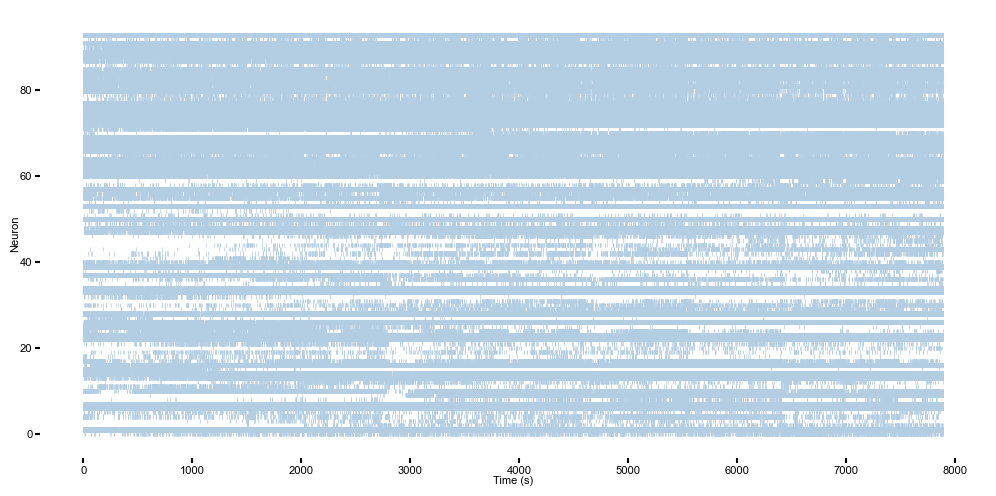

In [5]:
cmap = mpl.colormaps["Pastel1"]
color = cmap(1)
plt.figure(figsize=(10, 5))
plt.eventplot(spikes, linewidths=0.5, colors=color) 
plt.xlabel("Time (s)")
plt.ylabel("Neuron")

# hide the right and top spines
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.tight_layout()

In [6]:
trials_df.head()

,id,t,trialtype,cs,us,vacuum,opto_on,opto_off,ustype,us_stop,cstype,first_lick
0,1,630.818133,ODOR-ON_1,NaN,631.343300,NaN,NaN,NaN,Odor,641.322667,NaN,631.344
1,2,671.726933,ODOR-ON_1,NaN,672.246433,NaN,NaN,NaN,Odor,682.248533,NaN,NaN
2,3,712.516267,ODOR-ON_1,NaN,713.060933,NaN,NaN,NaN,Odor,723.054933,NaN,NaN
3,4,753.399467,PAUSE_120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,875.153067,TONE_1_LAG_500_REW_1_LAG_2000_VACUUM_1,875.656533,877.389600,879.399833,NaN,NaN,REW_1,NaN,NaN,880.039


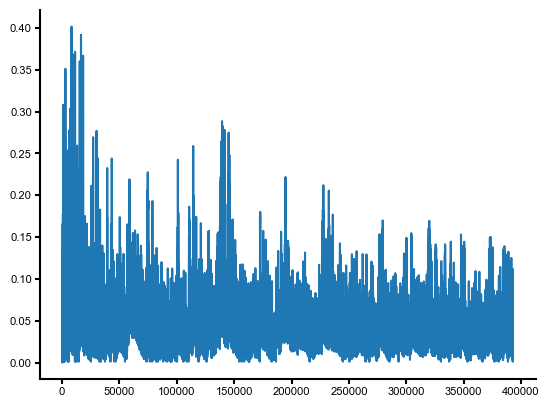

In [7]:
plt.plot(neuromod_activity)

### Split baseline period into training and testing samples and filter out neurons with little activity

In [8]:
trials_dir = os.path.join(data_dir, 'trials') 
trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

In [9]:
def get_block(spike_counts, neuromod_activity, t_start, t_end):
    block_dur = int((t_end - t_start) / bin_size)
    block_start_idx = int(t_start / bin_size) 
    spike_counts_block = spike_counts[:, block_start_idx:block_start_idx + block_dur]
    s_block = neuromod_activity[block_start_idx:block_start_idx + block_dur]
    return spike_counts_block, s_block 

#### Get last 20 minutes block

In [11]:
spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
spike_counts_pt_baseline = (spike_counts_pt_baseline - spike_counts_pt_baseline.mean()) / spike_counts_pt_baseline.std()


#### Get airpuff blocks

In [12]:
airpuff_trial_times = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['t'].astype('int').to_list()
airpuff_blocks = [] 
print(airpuff_trial_times)
# for each trial time, get a 20s block of neural and neuromodulatory activity
for t in airpuff_trial_times:
    t_start, t_end = t - 10, t + 10
    # convert to ms
    t_start, t_end = int(t_start // bin_size), int(t_end // bin_size) 
    airpuff_blocks.append([t_start, t_end])
print(airpuff_blocks)

[2914, 2970, 3026, 3827, 3882, 3938]
[[145199, 146199], [147999, 148999], [150799, 151799], [190849, 191849], [193599, 194599], [196399, 197399]]


### Load models

In [10]:
models = {}
neuromodulation = ['None', 'additive']
filters = ['']
folds = np.arange(1, 11)

for neuromod in neuromodulation:
    for fold in range(1, 11):
        for filter in filters:
            if neuromod == 'None' and filter != '': continue 
            try:
                vae, params, task_params, training_params = load_model(f'../../models/dtt/dtt_{neuromod}_rank_4_94_gauss_fold_{fold}{filter}')
                models[(neuromod+filter, fold)] = vae
            except: 
                print(f'Not found: {neuromod, fold, filter}')            

c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\recordings\../..\vi_rnn\saving.py:159: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io

dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Ne

### 2. Baseline evaluation

#### 2.1. Generate spikes for baseline testing period

In [16]:
def get_stats(vae, neuromod, seq_periods_eval, fold, out_likelihood='Gauss'):
    kl_divs, lls, mres = [], [], []
    data = torch.from_numpy(spike_counts).to(torch.float32)
    for block in seq_periods_eval:
        block_start = block[0] 
        block_end = block[1] 
        data[:, block_start:block_end] = (data[:, block_start:block_end] - data[:, block_start:block_end].mean()) / (data[:, block_start:block_end].std())
        print(block_start, block_end)
        T = block_end - block_start 
        z_hat, _, _, _ = vae.encoder(data[:, block_start:block_end].unsqueeze(0))
        z0 = z_hat[:, :, 0].squeeze() 
        sim_s, s_test_block = False, None 
        if neuromod != 'None':
            s_test_block = torch.from_numpy(neuromod_activity[block_start:block_end]).to(torch.float32).view(1, 1, -1)
        if 'additive' in neuromod:
            Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=False, sim_s=True)
            out = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
        else: 
            Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=False, sim_s = False)
            out = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]

        if out_likelihood == 'Poisson':
            out = torch.poisson(out).T.detach()
        if neuromod == 'additive':
            fig, ax = plt.subplots(6, 10, figsize=(15, 15))
            idx_i, idx_j = 0, 0
            for i in range(60):
                ax[idx_i, idx_j].plot(data[i, block_start:block_end], label=f'Neural activity')
                ax[idx_i, idx_j].plot(out[i, :].detach(), label=f'Predicted Neural activity')
                idx_j += 1
                if idx_j >= 10: 
                    idx_i, idx_j = idx_i + 1, 0
            
        kl_div = compute_KL_divergence(out.unsqueeze(0), data[:, block_start:block_end].unsqueeze(0))
        mr = mean_rate(out.detach().numpy(), data[:, block_start:block_end].numpy())
        _, _, _, _, _, _, ll, _ = vae.forward_Optimal_VGTF(data[:, block_start:block_end].unsqueeze(0), 
                                                   s=s_test_block, 
                                                   sim_s=sim_s, 
                                                   sim_v=False, 
                                                   resample='systematic', 
                                                   u=torch.zeros((1, 0, T)))
        print(neuromod, fold, kl_div, mr, ll)
        kl_divs.append(kl_div) 
        mres.append(mr)
        lls.append(ll.item()) 
    
    return kl_divs, mres, lls

In [11]:
kf = KFold(n_splits=10, shuffle=False)
rank, N = 4, spike_counts.shape[0]
spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
# z-score 
spike_counts_pt_baseline = (spike_counts_pt_baseline - spike_counts_pt_baseline.mean()) / spike_counts_pt_baseline.std()

for fold, (train_idx, test_idx) in enumerate(kf.split(s_pt_baseline), start=1):
    if fold != 5: continue 
    block_1 = train_idx[train_idx < test_idx[0]]
    block_2 = train_idx[train_idx > test_idx[-1]]
    print(f'Fold: {fold}')
    seq_periods_eval = [[test_idx[0], test_idx[-1]]]
    test_samples = spike_counts_pt_baseline[:, test_idx[0]:test_idx[-1]]
    s_test = s_pt_baseline[test_idx[0]:test_idx[-1]]

    if len(block_1) > 0 and len(block_2) > 0:
        seq_periods = [[block_1[0], block_1[-1]], [block_2[0], block_2[-1]]]
        train_samples = np.hstack([spike_counts_pt_baseline[:, block_1[0]:block_1[-1]],
                                   spike_counts_pt_baseline[:, block_2[0]:block_2[-1]]])
    elif len(block_1) > 0: 
        seq_periods = [[block_1[0], block_1[-1]]]
    else: 
        seq_periods = [[block_2[0], block_2[-1]]]
        
    print(f'Train blocks: {seq_periods}')
    print(f'Test blocks: {seq_periods_eval}')

    task_params = {
        "dur": 100,
        "n_trials": 3000,
        "name": "",
        "dataset_name": data_dir,
    }

    if neuromodulation is not None:
        task = DTTDataset(task_params, 
                            spike_counts_pt_baseline.T, 
                            s_train=s_pt_baseline, 
                            s_test=s_test,
                            seq_periods=seq_periods,
                            seq_periods_eval=seq_periods_eval,
                            data_eval=test_samples.T)
    else:
        task = DTTDataset(task_params, 
                            spike_counts_pt_baseline.T, 
                            s_train=None, 
                            s_test=None,
                            seq_periods=seq_periods,
                            seq_periods_eval=seq_periods_eval,
                            data_eval=test_samples.T)
    vae = models[('additive', 5)]
    T, dim_x = task.data_eval.shape
    z_hat, _, _, _ = vae.encoder(task.data_eval[:T, :].T.unsqueeze(0))
    z0 = z_hat[:, :, :1].squeeze()
    Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, noise_scale=1, s=task.s_test.unsqueeze(0), sim_v=False, sim_s=True)
    obs = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
    print(compute_KL_divergence(obs.unsqueeze(0), task.data_eval))

Fold: 5
Train blocks: [[0, 17799], [22250, 44499]]
Test blocks: [[17800, 22249]]
no input


c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\recordings\../..\vi_rnn\evaluation.py:132: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3701.)
  pred_trajectories_ = pred_trajectories.T.reshape(n_trials*trial_dur, -1)


n outliers: 0.07199999999999995
11.352869033813477


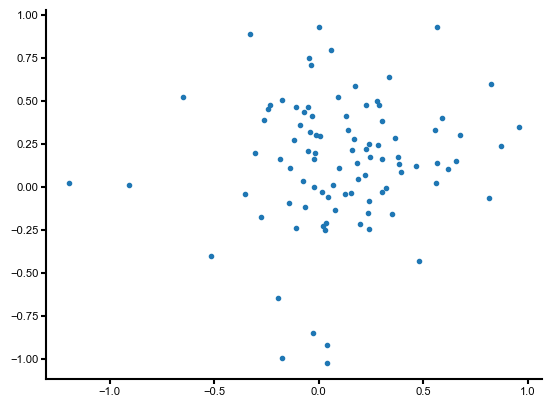

In [33]:
plt.scatter(models[('additive', 1)].rnn.transition.A.detach(), models[('additive', 10)].rnn.transition.A.detach())

In [44]:
from scipy.stats import pearsonr 
pearsonr(models[('additive', 4)].rnn.transition.A.detach().flatten(), models[('additive', 3)].rnn.transition.A.detach().flatten())

PearsonRResult(statistic=0.4166904470769528, pvalue=2.9464065922503897e-05)

In [18]:
kf = KFold(n_splits=10, shuffle=False)
model_kl_divs = {}
model_mres = {}
model_lls = {}

for fold, (train_idx, test_idx) in enumerate(kf.split(s_pt_baseline), start=1):
    print(f'Fold: {fold}')
    t_start = int(t_start_post_trial // bin_size)
    # get index of test blocks on spike_counts
    seq_periods_eval = [[t_start + test_idx[0], t_start + test_idx[-1]]] + [block for block in airpuff_blocks]
    # iterate over models and compute stats for current fold 
    for key in models.keys():
        model_name, model_fold = key 
        if model_fold == fold and model_name=='None':
            kl_divs, mres, lls = get_stats(models[key], model_name, seq_periods_eval, key[1])
            if key[0] not in model_lls: 
                model_kl_divs[model_name] = [kl_divs]
                model_lls[model_name] = [lls]
                model_mres[model_name] = [mres]
            else:
                model_kl_divs[model_name].append(kl_divs)
                model_lls[model_name].append(lls)
                model_mres[model_name].append(mres)

Fold: 1
348449 352898
no input
n outliers: 0.0
None 1 1.6506776809692383 633.8063609799955 tensor([-9.8424])
145199 146199
no input
n outliers: 0.0
None 1 8.55700969696045 3016.8525 tensor([-110.2613])
147999 148999
no input
n outliers: 0.0020000000000000018
None 1 13.486632347106934 2668.331 tensor([-77.9780])
150799 151799
no input
n outliers: 0.01100000000000001
None 1 18.843488693237305 3121.73275 tensor([-72.3844])
190849 191849
no input
n outliers: 0.0
None 1 3.5201492309570312 50.6034140625 tensor([-70.9489])
193599 194599
no input
n outliers: 0.0
None 1 4.75713586807251 67.4147421875 tensor([-88.7516])
196399 197399
no input
n outliers: 0.0
None 1 4.0087504386901855 70.55521875 tensor([-51.5010])
Fold: 2
352899 357348
no input
n outliers: 0.0
None 2 2.012448787689209 95.58327714093055 tensor([-15.6397])
145199 146199
no input
n outliers: 0.0
None 2 4.865545749664307 120.061203125 tensor([-85.2541])
147999 148999
no input
n outliers: 0.0
None 2 4.805058479309082 51.45767578125 t

In [17]:
type(neuromod_activity)

numpy.ndarray

In [21]:
model_kl_divs['None']

[[1.3401339054107666,
  4.968560695648193,
  4.898425102233887,
  4.467090129852295,
  3.9924519062042236,
  4.750738143920898,
  3.8843488693237305],
 [1.8730111122131348,
  4.87241268157959,
  4.768496513366699,
  4.6347856521606445,
  4.323957443237305,
  5.243790626525879,
  3.6112780570983887],
 [1.6031675338745117,
  4.524559020996094,
  5.418171405792236,
  4.810617446899414,
  4.758957862854004,
  4.614006042480469,
  3.6335289478302]]

In [20]:
model_mres['None']

[[38.00689389308735,
  75.310640625,
  58.11301953125,
  58.60062890625,
  62.81445703125,
  72.9550390625,
  63.22863671875],
 [21.277481801511446,
  85.9910078125,
  49.3481875,
  64.95141015625,
  103.255703125,
  70.848609375,
  45.00739453125],
 [44.89275741831518,
  70.705265625,
  57.39996875,
  64.9171875,
  75.5960078125,
  62.9167890625,
  64.0613984375]]

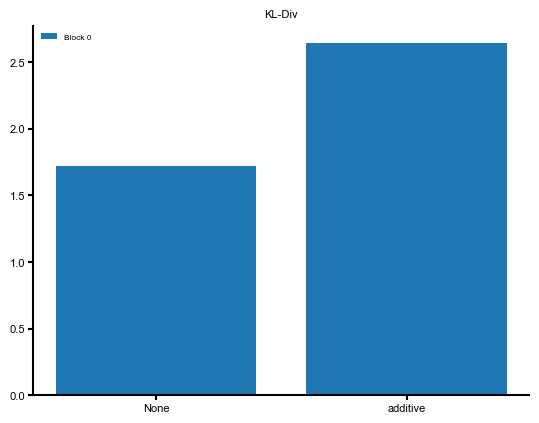

In [29]:
categories = ['None', 'additive']
x = np.arange(len(categories)) 
width = 0.8 / len(kl_div_2)
groups = []
for i in range(len(kl_div_1)): 
    plt.bar(x + i * width - (0.8 - width) / 2, [kl_div_2[i], kl_div_1[i]], width, label=f'Block {i}')
plt.legend()
plt.xticks(x, categories)
plt.title('KL-Div')
plt.legend()

In [20]:
def compute_nll(model, neuromod):
    ll_xs = {}

    ll_x_func = (
        lambda x, mu: torch.distributions.Poisson(mu)
        .log_prob(x)
        .sum()
    )
    vae = models[model]
    lls = []
    for i, block in enumerate(task.seq_periods_eval):
        block_start = block[0]
        block_end = block[1]
        T = block_end - block_start 
        sim_s, s_test_block = False, None 
        if neuromod != 'None':
            s_test_block = task.s_train[:, block_start:block_end].unsqueeze(0)
        if neuromod != 'None': sim_s = True 
        _, _, _, _, _, _, ll, _ = vae.forward_Optimal_VGTF(task.data[block_start:block_end, :].T.unsqueeze(0), 
                                                   s=s_test_block, 
                                                   sim_s=sim_s, 
                                                   sim_v=False, 
                                                #    out_likelihood='Gauss',
                                                   resample='systematic', 
                                                   u=torch.zeros((1, 0, task.data_eval.shape[0])))
        print(model, i, ll)
        lls.append(-ll.item())
    return lls

In [21]:
ll_nm = compute_nll(('additive', 3, 94, 'gauss'), 'additive')
ll_nn = compute_nll(('None', 3, 94, 'gauss'), 'None')


('additive', 3, 94, 'gauss') 0 tensor([-158.8621])
('None', 3, 94, 'gauss') 0 tensor([-16.7792])


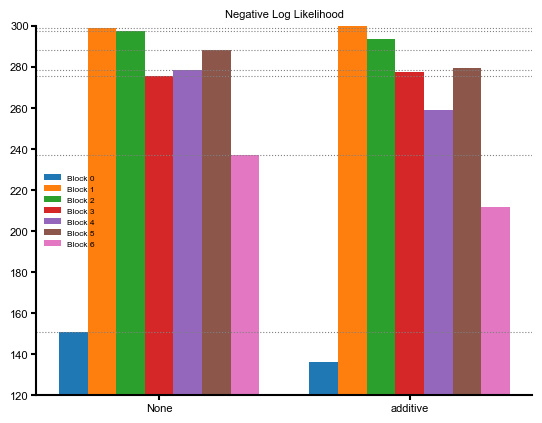

In [79]:
categories = ['None', 'additive']
x = np.arange(len(categories)) 
width = 0.8 / len(ll_nm)
groups = []
for i in range(len(kl_div_1)): 
    plt.bar(x + i * width - (0.8 - width) / 2, [ll_nn[i], ll_nm[i]], width, label=f'Block {i}')
    plt.axhline(y=ll_nn[i], color='gray', linestyle='dotted', linewidth=0.8)
plt.legend()
plt.xticks(x, categories)
plt.ylim(120, 300)
plt.title('Negative Log Likelihood')
plt.legend()

In [86]:
spike_preds[model_1].shape

torch.Size([94, 1000])

In [23]:
for i, block in enumerate(task.seq_periods_eval):
        block_start = block[0]
        block_end = block[1]
        T = block_end - block_start 
        mre_add = mean_rate(spike_preds[model_1].detach().numpy(), task.data[block_start:block_end, :].T.numpy())
        mre_none = mean_rate(spike_preds[model_2].detach().numpy(), task.data[block_start:block_end, :].T.numpy())
        print(mre_add, mre_none)

140.43258224049788 82.45973410757946


C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_26712\1598901890.py:18: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')


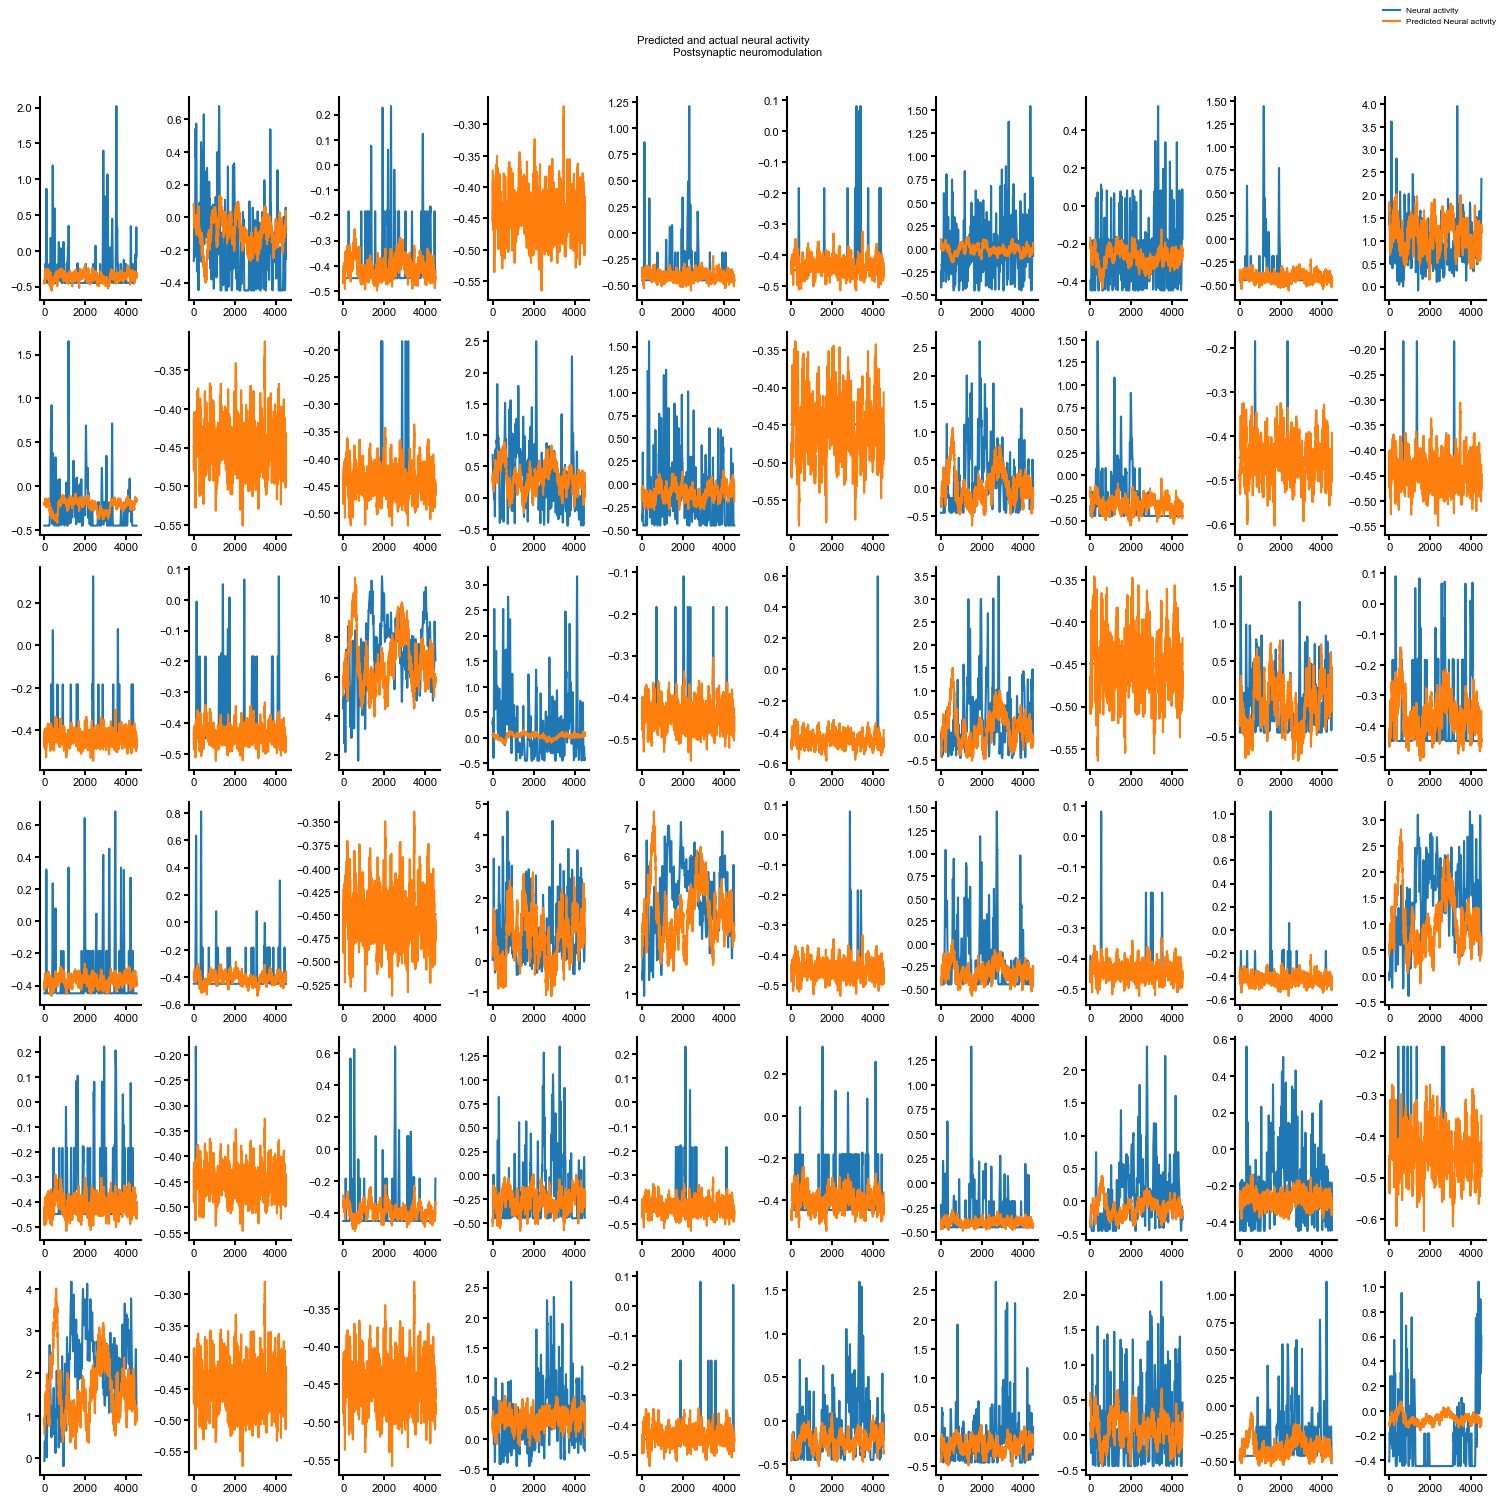

In [22]:
kl_div = []
# for b in range(10):
    # compute the KL-Divergence 
# block_idx = 6
block_start, block_end = task.seq_periods_eval[block_idx]
# kl_div_b = compute_KL_divergence(spike_preds[model_2].unsqueeze(0), task.data_eval[block_start:block_end, :].T.unsqueeze(0))
# kl_div.append(kl_div_b) 
# plot population activity 
fig, ax = plt.subplots(6, 10, figsize=(15, 15))
idx_i, idx_j = 0, 0
for i in range(60):
    ax[idx_i, idx_j].plot(task.data[block_start:block_end, i], label=f'Neural activity')
    ax[idx_i, idx_j].plot(spike_preds[model_2][i, :].detach(), label=f'Predicted Neural activity')
    idx_j += 1
    if idx_j >= 10: 
        idx_i, idx_j = idx_i + 1, 0
    
fig.legend([idx_i, idx_j], labels=['Neural activity', 'Predicted Neural activity'], loc='upper right')
fig.suptitle(f"Predicted and actual neural activity\
                \nPostsynaptic neuromodulation")
plt.tight_layout(rect=[0, 0, 1, 0.97])
    # fig.savefig(f"{figures_dir}/mante postsynaptic rank 2/plot_{b}.png")
    # plt.show()
    
    

In [19]:
spike_preds.keys()

dict_keys([('additive', 3, 81, 'gauss', 0), ('None', 3, 81, 'gauss', 0)])

#### 2.2. Compute evaluation metrics between generated and test spikes

In [36]:
from scipy.stats import pearsonr
# Parameters
tau = 4  # Decay time constant

model_vrds = {} # Van Rossum distances 
model_mres = {} # mean-rate errors 
model_isis = {} # model inter-spike interval
num_neurons = 94

for model in spike_preds.keys():
    vrds = np.zeros((num_neurons,))
    mres = np.zeros_like(vrds) 
    block_idx = model[-1] 
    block_start, block_end = task.seq_periods_eval[block_idx]
    T = block_end - block_start 
    for j in range(num_neurons):
        vrd = van_rossum_distance(spike_preds[model][:, j], task.data_eval[block_start:block_end, j], tau, T) 
        
        vrds[j] = vrd 
        # mean_rates_gen = spike_preds[model][:, j].sum() / (bin_size * T) 
        # mean_rates_test = task.data_eval[block_start:block_end, j].sum() / (bin_size * T)
        # mre = np.abs(mean_rates_gen - mean_rates_test) 
        # mres[j] = mean 
    mres = mean_rate(spike_preds[model].T.numpy(), task.data_eval[block_start:block_end, :].T.numpy())
    _, isi_stats_gen, _ = calc_isi_stats(spike_preds[model]) 
    _, isi_stats_test, _ = calc_isi_stats(task.data_eval[block_start:block_end, :])
    isi_stats_gen = np.nan_to_num(isi_stats_gen)
    isi_stats_test = np.nan_to_num(isi_stats_test)

    # mean_corr = pearsonr(isi_stats_gen, isi_stats_test)[0]
    isi_err = np.abs(isi_stats_gen - isi_stats_test).sum()
    model_vrds[model] = (vrds.sum())
    model_mres[model] = (mres.sum()) 

    print(f'{model}: VRD: {model_vrds[model]}, MRE: {model_mres[model]}, ISI mean corr: {isi_err}')

c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


('None', 3, 94, '', 0): VRD: 849.644527466372, MRE: 33.412953389830506, ISI mean corr: 53418.90476836901
('None', 3, 94, '', 1): VRD: 211.17560996804735, MRE: 3.817095703125, ISI mean corr: 4684.155539849698
('None', 3, 94, '', 2): VRD: 208.28136581305745, MRE: 2.395680908203125, ISI mean corr: 4453.029838932121
('None', 3, 94, '', 3): VRD: 206.79173824491258, MRE: 1.38625537109375, ISI mean corr: 4804.2759892357735
('None', 3, 94, '', 4): VRD: 216.8499247675614, MRE: 2.06544677734375, ISI mean corr: 4426.003703007545
('None', 3, 94, '', 5): VRD: 235.0122033274381, MRE: 4.3088828125, ISI mean corr: 4190.364738666703
('None', 3, 94, '', 6): VRD: 239.57260155586533, MRE: 4.159904296875, ISI mean corr: 5005.200543262952
('None', 3, 256, '', 0): VRD: 842.6342444353043, MRE: 23.85456991525424, ISI mean corr: 37971.50897637075
('None', 3, 256, '', 1): VRD: 217.6177294046342, MRE: 2.50324462890625, ISI mean corr: 4466.531452533483
('None', 3, 256, '', 2): VRD: 213.145893668233, MRE: 0.7269574

In [33]:
model = ('additive', 3, 94, '', block_idx)
_, isi_stats_gen, _ = calc_isi_stats(spike_preds[model]) 
_, isi_stats_test, _ = calc_isi_stats(task.data_eval[block_start:block_end, :])
isi_stats_gen = np.nan_to_num(isi_stats_gen)
isi_stats_test = np.nan_to_num(isi_stats_test)


c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\kaleab.belay\.conda\envs\py3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


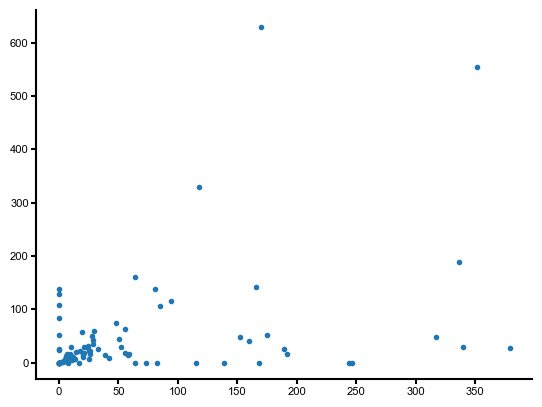

In [34]:
plt.scatter(isi_stats_gen, isi_stats_test)

#### 2.3. Compute the log-likelihood of the test data under models

#### Compare PSTH of each model around airpuff trials

In [35]:
spike_preds[('additive', 3, 94, 'deconvolved', 0)].shape

torch.Size([7375, 94])

In [19]:
def get_bins(spike_preds, t, window_size):
    # get binned spike counts centered at time t
    # get bin index 
    bin_idx = t / bin_size 
    return spike_preds[bin_idx - window_size:bin_idx + window_size]

In [20]:
def get_psth(bins, bin_size_psth = 20):
    t = bins.shape[0] // 2
    print(t, bins.shape)
    # re-bin to the desired bin size 
    # hist_left = [bins[i:i + bin_size_psth, :].sum(axis=0) for i in range(t - bin_size_psth, 0, -bin_size_psth)]
    hist_right = [bins[i:i + bin_size_psth:].sum(axis=0) for i in range(0, bins.shape[0] - bin_size_psth, bin_size_psth)]
    # print(len(hist_left), len(hist_right))
    # psth = np.hstack([hist_left, hist_right])
    return np.array(hist_right)
    return psth 

In [21]:
airpuff_trial_times

[145744, 148534, 151322, 191356, 194143, 196935]

In [77]:
neuromod, rank, N, filtered, block_idx = 'additive', 3, 512, 'unfiltered', 3
model1 = (neuromod, rank, N, filtered, block_idx)
model2 = ('None', rank, N, filtered, block_idx)
psth_model_1 = get_psth(spike_preds[model1])
psth_model_2 = get_psth(spike_preds[model2])
block_start, block_end = task.seq_periods_eval[block_idx]
psth_test = get_psth(task.data_eval[block_start:block_end, :])

500 torch.Size([1000, 94])
500 torch.Size([1000, 94])
500 torch.Size([1000, 94])


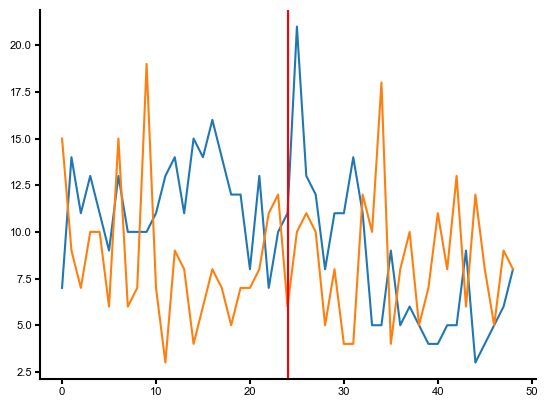

In [98]:
neur_idx = 34
plt.plot(psth_test[:, neur_idx])
plt.plot(psth_model_1[:, neur_idx])
center = len(psth_test[:, neur_idx]) // 2 
plt.axvline(center, c='r')

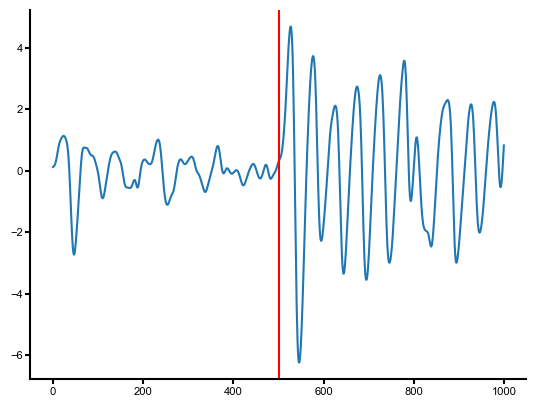

In [97]:
plt.plot(task.s_test[0, block_start:block_end])
plt.axvline(500, color='r')

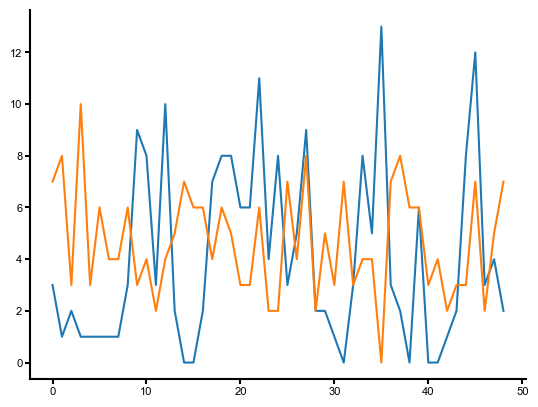

In [85]:
neur_idx = 33
plt.plot(psth_test[:, neur_idx])
plt.plot(psth_model_2[:, neur_idx])


### Compare models per trial block

In [85]:
dataloader = DataLoader(
        task, batch_size=256, shuffle=True
    )
data_sample = next(iter(dataloader)) 
inputs, stim, s = data_sample
sim_s = False 
s = None 
ll, _, _, _, _, _, _, _ = models[('no_neuromodulation', 3, 512)].forward_VGTF(inputs, s=s, sim_s=sim_s, sim_v=False, resample='systematic', u=stim)

In [86]:
ll.mean().item()

-120.94171905517578

In [77]:
test = task.data[t_start:t_start + 100, :].T.unsqueeze(0)
s_block = task.s_train[:, t_start:t_start+100]
models[('additive', 3, 95)].eval()
loss, _, _, _, _, _, ll, _ = models[('additive', 3, 95)].forward_VGTF(test, s=s_block.unsqueeze(0), sim_s=True, sim_v=False, resample='systematic', u=torch.zeros((1, 0, task.data_eval.shape[0])))
ll, loss 

(tensor([-95.5780]), tensor([-95.5780], grad_fn=<MeanBackward1>))

In [31]:
from scipy.stats import pearsonr
pearsonr(weights1.flatten(), weights2.flatten())

PearsonRResult(statistic=0.19128293795482826, pvalue=0.06477095998975796)

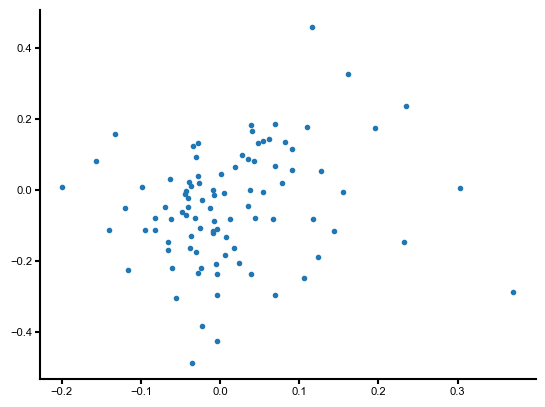

In [28]:
weights1 = models[('additive', 3, 94, 'deconvolved')].rnn.transition.A.detach()
weights2 = models[('additive', 3, 94, 'calcium')].rnn.transition.A.detach()

plt.scatter(weights1, weights2)

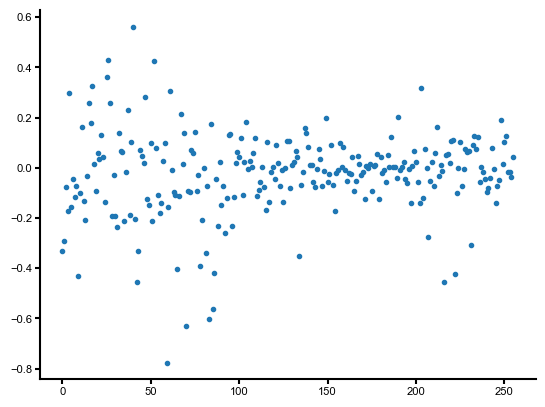

In [88]:
plt.scatter(np.arange(0, models[('additive', 3, 256)].rnn.transition.A.shape[0]), models[('additive', 3, 256)].rnn.transition.A.detach())

In [33]:
lmd.shape, data_eval.shape

(torch.Size([81, 7500]), torch.Size([7500, 81]))

In [36]:
mean_rate_errors.sum(axis=1), mean_rate_errors.mean(axis=1)

(array([156.72542383, 158.61695064]), array([1.93488178, 1.95823396]))

### Compute log likelihood of test data under models

In [80]:
test_samples.shape

(111, 33750)

In [ ]:
data_eval = torch.from_numpy(test_samples.T).to(torch.float32)[start_latent:T, :]
for neuromod in neuromodulation: 
    for rank in [1, 2, 3, 4]:
        vae = models[(neuromod, rank)]
        z_hat, _, _, _ = vae.encoder(data_eval.T.unsqueeze(0))
        lmd = vae.rnn.get_observation(z_hat, noise_scale=0)[0, :, :, 0]
        

### Plot latent activity of Rank 2 network

In [79]:
z_hat, _, _, _ = models[1].encoder(data_eval.T.unsqueeze(0))
# z0 = z_hat[:, :, :1].squeeze() 
z0 = torch.tensor([-59, 10]).to(torch.float32)
Z = models[1].rnn.get_latent_time_series(time_steps=T, cut_off=1000, z0=z0, noise_scale=1.0, sim_v=False)
# Z = Z.reshape(-1, 2)

no input


Text(0.5, 1.0, 'Latent trajectory for predictions over test set')

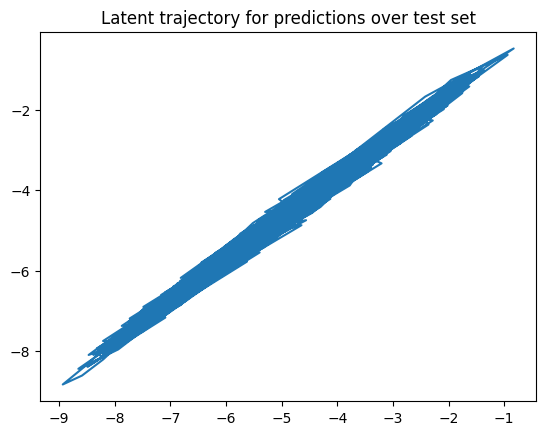

In [ ]:
plt.plot(Z[0, 0, :, 0], Z[0, 1, :, 0])
plt.title('2D Latent trajectory for predictions over test set')

Text(0.5, 1.0, 'Latent trajectory for predictions over test set')

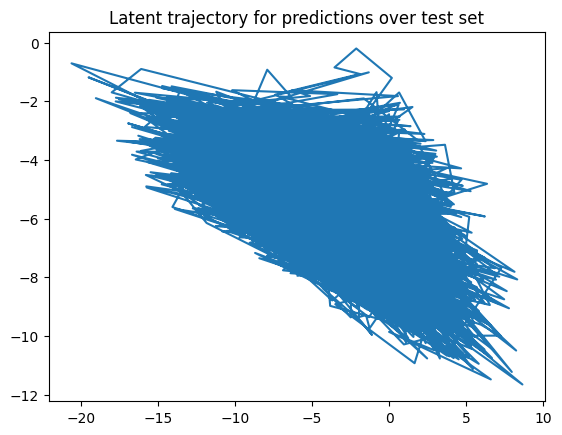

In [85]:
z_hat = z_hat.detach()
plt.plot(z_hat[0, 0, :, 0], z_hat[0, 1, :, 0])
plt.title('Latent trajectory for predictions over test set')

### Plot latent trajectory of Rank 3 model

In [87]:
z_hat, _, _, _ = models[2].encoder(data_eval.T.unsqueeze(0))
z0 = z_hat[:, :, :1].squeeze() 
# z0 = torch.tensor([-59, 10]).to(torch.float32)
Z = models[2].rnn.get_latent_time_series(time_steps=T, cut_off=1000, z0=z0, noise_scale=1.0, sim_v=False)
# Z = Z.reshape(-1, 2)

no input


Text(0.5, 0.92, '3D Latent trajectory')

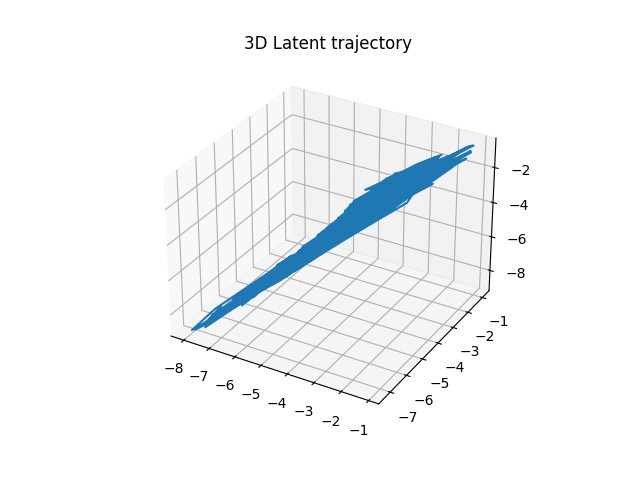

In [90]:
%matplotlib ipympl
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(Z[0, 0, :, 0], Z[0, 1, :, 0], Z[0, 2, :, 0])
ax.set_title('3D Latent trajectory')